In [1]:
import pandas as pd
import pandas as pd
import scanpy as sc
import pickle
import os
import anndata as ad
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

In [2]:
feat_data = pickle.load(open(os.path.join('lowdimention', f"PBMC_TEA_embedding_dual.pkl"), "rb"))

z_joint = feat_data['z_joint']

y_pred_joint = feat_data['y_pred_joint']

In [3]:
cluster_df = pd.read_csv("data/PBMC_TEA/PBMC_TEA_cluster.csv")

true_labels = cluster_df["celltype"].values

In [4]:
adata = ad.AnnData(z_joint)
adata.obs["y_pred"]=pd.Categorical(y_pred_joint)
adata.obs['y'] = true_labels

In [5]:
adata

AnnData object with n_obs × n_vars = 6194 × 32
    obs: 'y_pred', 'y'

In [6]:
nmi = normalized_mutual_info_score(true_labels, y_pred_joint)
ari = adjusted_rand_score(true_labels, y_pred_joint)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.6987
ARI: 0.5452


In [7]:
sc.pp.neighbors(adata, use_rep = 'X', key_added = "Deal", n_neighbors = 15)

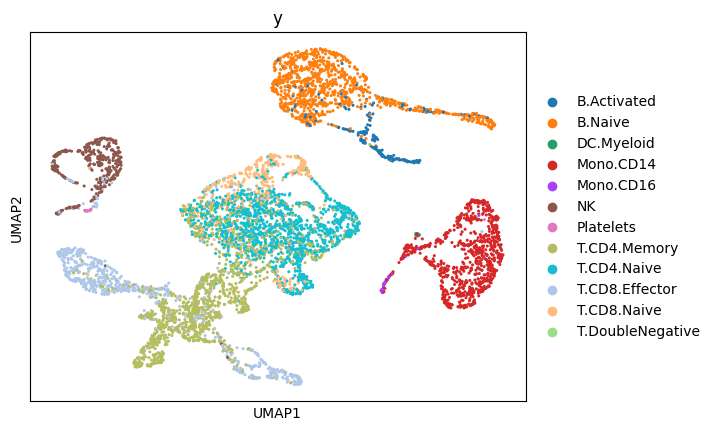

In [8]:
sc.tl.umap(adata, neighbors_key= "Deal")
sc.pl.umap(adata, color='y', show=True)

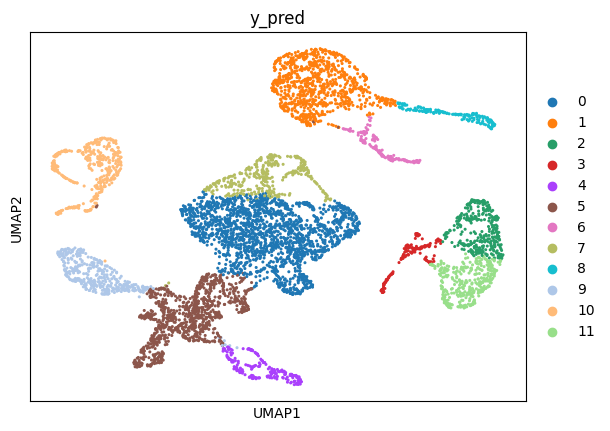

In [9]:
sc.pl.umap(adata, color='y_pred', show=True)